# Consultoría - Hyundai Heavy Industries
Diego Duarte
Paula Barillas

In [1]:
!pip -q install pyspark

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Lab Spark — Hyundai Heavy Industries").getOrCreate()
print("Spark version:", spark.version)

Spark version: 3.5.1


In [3]:
df_hundai = spark.read.csv("barcos_crucero.csv", header=True, inferSchema=True)

### Descripcion de Datos

In [4]:
df_hundai.show(5)

+-----------+-----------+---+------------------+----------+------+------+-----------------+----+
|  Ship_name|Cruise_line|Age|           Tonnage|passengers|length|cabins|passenger_density|crew|
+-----------+-----------+---+------------------+----------+------+------+-----------------+----+
|    Journey|    Azamara|  6|30.276999999999997|      6.94|  5.94|  3.55|            42.64|3.55|
|      Quest|    Azamara|  6|30.276999999999997|      6.94|  5.94|  3.55|            42.64|3.55|
|Celebration|   Carnival| 26|            47.262|     14.86|  7.22|  7.43|             31.8| 6.7|
|   Conquest|   Carnival| 11|             110.0|     29.74|  9.53| 14.88|            36.99|19.1|
|    Destiny|   Carnival| 17|           101.353|     26.42|  8.92| 13.21|            38.36|10.0|
+-----------+-----------+---+------------------+----------+------+------+-----------------+----+
only showing top 5 rows



In [5]:
print(f"Total de registros: {df_hundai.count()}")
print(f"Total de columnas: {len(df_hundai.columns)}")

# Imprimir tipos de datos
df_hundai.printSchema()

Total de registros: 158
Total de columnas: 9
root
 |-- Ship_name: string (nullable = true)
 |-- Cruise_line: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Tonnage: double (nullable = true)
 |-- passengers: double (nullable = true)
 |-- length: double (nullable = true)
 |-- cabins: double (nullable = true)
 |-- passenger_density: double (nullable = true)
 |-- crew: double (nullable = true)



In [6]:
from pyspark.sql.functions import col, isnan, count, mean, stddev, min, max, when

df_hundai.select([count(when(col(c).isNull() | isnan(c) | (col(c) == ""), c)).alias(c) for c in df_hundai.columns]).show()

+---------+-----------+---+-------+----------+------+------+-----------------+----+
|Ship_name|Cruise_line|Age|Tonnage|passengers|length|cabins|passenger_density|crew|
+---------+-----------+---+-------+----------+------+------+-----------------+----+
|        0|          0|  0|      0|         0|     0|     0|                0|   0|
+---------+-----------+---+-------+----------+------+------+-----------------+----+



In [7]:
numeric_cols = [c for c, t in df_hundai.dtypes if t in ('double', 'int')]
df_hundai.select(numeric_cols).describe().show()

+-------+------------------+------------------+-----------------+-----------------+------------------+-----------------+-----------------+
|summary|               Age|           Tonnage|       passengers|           length|            cabins|passenger_density|             crew|
+-------+------------------+------------------+-----------------+-----------------+------------------+-----------------+-----------------+
|  count|               158|               158|              158|              158|               158|              158|              158|
|   mean|15.689873417721518| 71.28467088607599|18.45740506329114|8.130632911392404| 8.830000000000005|39.90094936708861|7.794177215189873|
| stddev| 7.615691058751413|37.229540025907866|9.677094775143416|1.793473548054825|4.4714172221480615| 8.63921711391542|3.503486564627034|
|    min|                 4|             2.329|             0.66|             2.79|              0.33|             17.7|             0.59|
|    max|                48

In [8]:
df_hundai.groupBy("Cruise_line").count().orderBy(col("count").desc()).show()

+-----------------+-----+
|      Cruise_line|count|
+-----------------+-----+
|  Royal_Caribbean|   23|
|         Carnival|   22|
|         Princess|   17|
| Holland_American|   14|
|        Norwegian|   13|
|            Costa|   11|
|        Celebrity|   10|
|              MSC|    8|
|              P&O|    6|
|             Star|    6|
|Regent_Seven_Seas|    5|
|        Silversea|    4|
|           Cunard|    3|
|         Seabourn|    3|
|         Windstar|    3|
|          Oceania|    3|
|          Crystal|    2|
|           Disney|    2|
|          Azamara|    2|
|           Orient|    1|
+-----------------+-----+



In [9]:
for c in numeric_cols:
    if c != "crew":
        corr = df_hundai.stat.corr("crew", c)
        print(f"Correlación Tripulación ↔ {c}: {corr:.3f}")

Correlación Tripulación ↔ Age: -0.531
Correlación Tripulación ↔ Tonnage: 0.928
Correlación Tripulación ↔ passengers: 0.915
Correlación Tripulación ↔ length: 0.896
Correlación Tripulación ↔ cabins: 0.951
Correlación Tripulación ↔ passenger_density: -0.156


##  Hyundai Heavy Industries

El conjunto de datos contiene **158 registros** correspondientes a barcos de distintas líneas de cruceros.  
Cada registro describe las características físicas, capacidad y personal de tripulación del barco.  

**No se detectaron valores nulos** en ninguna columna, y los tipos de datos son consistentes entre variables numéricas y categóricas.

A nivel general:

- **Edad promedio de los barcos:** 15.7 años  
- **Tonelaje promedio:** 71.3 mil toneladas  
- **Pasajeros promedio:** 1,846  
- **Cabinas promedio:** 883  
- **Tripulación promedio:** 779 personas  

Las líneas de cruceros más representadas son *Royal Caribbean*, *Carnival* y *Princess*, que concentran la mayor parte de los barcos del dataset.

En cuanto a correlaciones con la cantidad de tripulación:

| Variable | Correlación | Interpretación |
|-----------|-------------|----------------|
| Cabinas | **0.951** | Relación más fuerte; más cabinas → más tripulación |
| Tonelaje | **0.928** | Barcos más grandes necesitan más personal |
| Pasajeros | **0.915** | A más pasajeros, más tripulación |
| Longitud | **0.896** | Mayor tamaño físico → más personal |
| Edad | -0.531 | Barcos más antiguos suelen tener menos tripulación |
| Densidad de pasajeros | -0.156 | Relación débil o nula |

**Conclusiones:**  
El dataset es limpio, completo y adecuado para el modelado.  
Las variables que más influyen en la cantidad de tripulación son las relacionadas con el **tamaño y capacidad del barco** (cabinas, tonelaje, pasajeros y longitud).  
La antigüedad también tiene cierto impacto negativo.  
Este análisis proporciona una base sólida para el desarrollo del **modelo de regresión lineal predictivo**.


## Modelo

In [10]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Variables predictoras (puedes ajustar según correlación)
features = ["Age", "Tonnage", "passengers", "length", "cabins", "passenger_density"]

# Crear el vector de características
assembler = VectorAssembler(inputCols=features, outputCol="features")

# Transformar el dataset
df_model = assembler.transform(df_hundai).select("features", "crew")
df_model.show(5, truncate=False)


+---------------------------------------------+----+
|features                                     |crew|
+---------------------------------------------+----+
|[6.0,30.276999999999997,6.94,5.94,3.55,42.64]|3.55|
|[6.0,30.276999999999997,6.94,5.94,3.55,42.64]|3.55|
|[26.0,47.262,14.86,7.22,7.43,31.8]           |6.7 |
|[11.0,110.0,29.74,9.53,14.88,36.99]          |19.1|
|[17.0,101.353,26.42,8.92,13.21,38.36]        |10.0|
+---------------------------------------------+----+
only showing top 5 rows



In [11]:
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)
print("Datos de entrenamiento:", train_data.count())
print("Datos de prueba:", test_data.count())

Datos de entrenamiento: 133
Datos de prueba: 25


In [12]:
lr = LinearRegression(featuresCol="features", labelCol="crew")

# Entrenar
lr_model = lr.fit(train_data)

# Resultados del entrenamiento
training_summary = lr_model.summary
print(f"RMSE (Entrenamiento): {training_summary.rootMeanSquaredError:.3f}")
print(f"R² (Entrenamiento): {training_summary.r2:.3f}")

RMSE (Entrenamiento): 1.004
R² (Entrenamiento): 0.922


In [13]:
test_results = lr_model.evaluate(test_data)
print(f"RMSE (Prueba): {test_results.rootMeanSquaredError:.3f}")
print(f"R² (Prueba): {test_results.r2:.3f}")

RMSE (Prueba): 0.683
R² (Prueba): 0.935


In [14]:
print("Intercepto:", lr_model.intercept)
for name, coef in zip(features, lr_model.coefficients):
    print(f"{name}: {coef:.3f}")

Intercepto: -0.588212330747945
Age: -0.011
Tonnage: 0.013
passengers: -0.149
length: 0.398
cabins: 0.803
passenger_density: 0.001


In [15]:
nuevos_barcos = spark.createDataFrame([
    (8, 130, 30, 10.5, 14, 35),
    (5, 200, 50, 11.5, 22, 40)
], features)

# Transformar y predecir
nuevos_barcos_vector = assembler.transform(nuevos_barcos)
predicciones = lr_model.transform(nuevos_barcos_vector)

predicciones.select("features", "prediction").show(truncate=False)

+-------------------------------+------------------+
|features                       |prediction        |
+-------------------------------+------------------+
|[8.0,130.0,30.0,10.5,14.0,35.0]|12.063417691091528|
|[5.0,200.0,50.0,11.5,22.0,40.0]|16.88606956144691 |
+-------------------------------+------------------+



## Visualización de Datos

### Mapa de Calor de Correlaciones

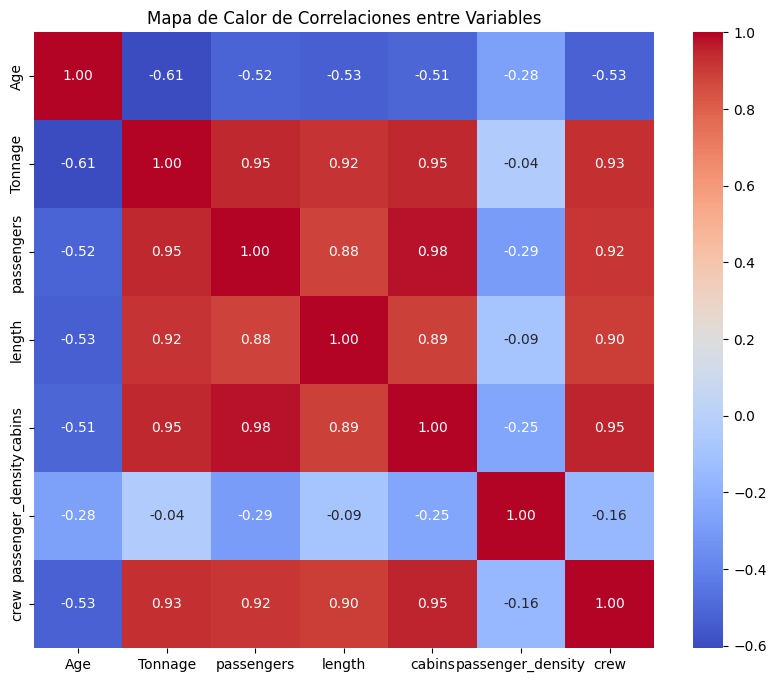

In [17]:
# Convert the DataFrame of Spark to Pandas for graficar
df_pandas = df_hundai.select("Age", "Tonnage", "passengers", "length", "cabins", "passenger_density", "crew", "Cruise_line").toPandas()
# Gráfico de correlación entre variables numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(df_pandas.drop('Cruise_line', axis=1).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Calor de Correlaciones entre Variables")
plt.show()

### Relación entre Tonelaje y Tripulación

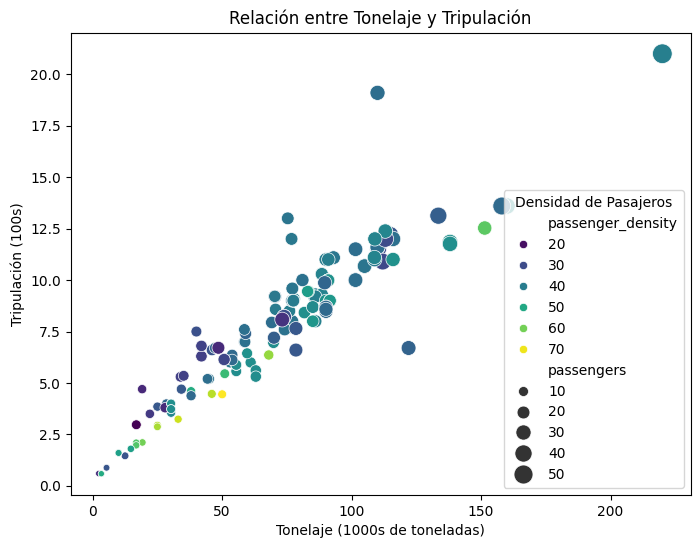

In [18]:
# Gráfico de dispersión entre 'Tonnage' y 'crew'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pandas, x='Tonnage', y='crew', hue='passenger_density', size='passengers', sizes=(20, 200), palette="viridis")
plt.title("Relación entre Tonelaje y Tripulación")
plt.xlabel("Tonelaje (1000s de toneladas)")
plt.ylabel("Tripulación (100s)")
plt.legend(title="Densidad de Pasajeros")
plt.show()

### Distribución de Barcos por Línea de Cruceros

/tmp/ipython-input-3945402197.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pandas, y='Cruise_line', order=df_pandas['Cruise_line'].value_counts().index, palette="muted")


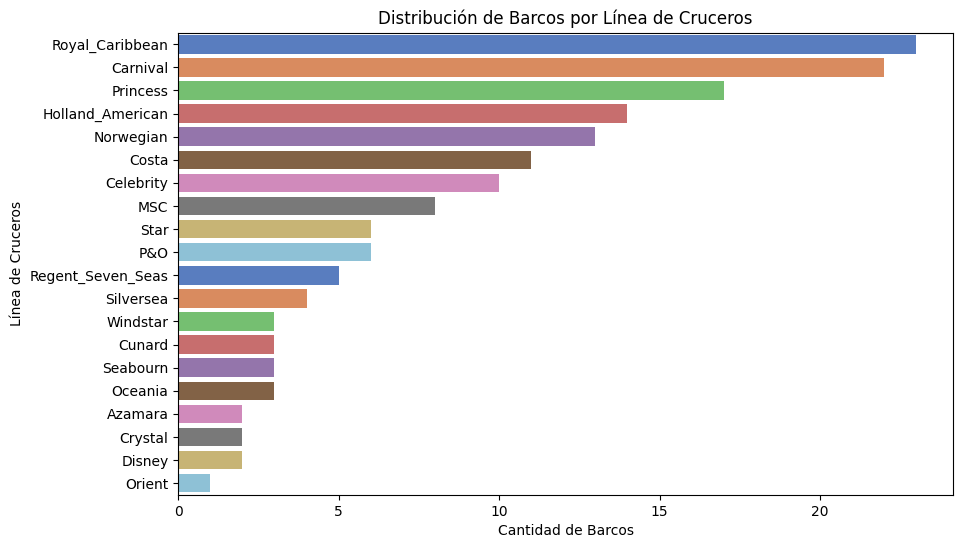

In [19]:
# Gráfico de barras para líneas de cruceros más representadas
plt.figure(figsize=(10, 6))
sns.countplot(data=df_pandas, y='Cruise_line', order=df_pandas['Cruise_line'].value_counts().index, palette="muted")
plt.title("Distribución de Barcos por Línea de Cruceros")
plt.xlabel("Cantidad de Barcos")
plt.ylabel("Línea de Cruceros")
plt.show()

### Relación entre Edad y Tripulación

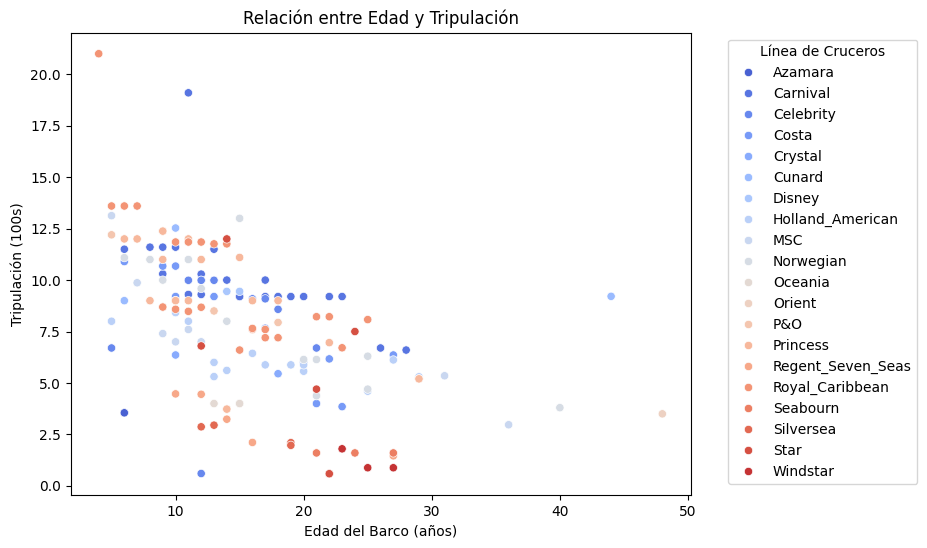

In [20]:
# Gráfico de dispersión entre 'Age' y 'crew'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pandas, x='Age', y='crew', hue='Cruise_line', palette="coolwarm")
plt.title("Relación entre Edad y Tripulación")
plt.xlabel("Edad del Barco (años)")
plt.ylabel("Tripulación (100s)")
plt.legend(title="Línea de Cruceros", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()